<a href="https://colab.research.google.com/github/Roger-Quinelato/dtLab-2/blob/colab/Quest%C3%A3o_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
#Bibliotecas
!pip install deepface opencv-python-headless matplotlib scipy

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2
from deepface import DeepFace
from scipy.spatial.distance import cosine
import pickle
import time


In [96]:
# Célula 2: Carregar o modelo
print("--- Fase 2: Carregando o Modelo de Reconhecimento Facial ---")

# Carrega o modelo ArcFace.
# A primeira execução pode levar alguns minutos para baixar os pesos do modelo.
try:
    _ = DeepFace.build_model('ArcFace')
    print("\nModelo 'ArcFace' carregado com sucesso.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o modelo: {e}")

--- Fase 2: Carregando o Modelo de Reconhecimento Facial ---

Modelo 'ArcFace' carregado com sucesso.


In [97]:
# Célula 3 (Definitiva e Final - Usa seu Cache Existente)
print("--- Fase 3 (Definitiva): Preparando o Banco de Dados Final a partir do Cache ---")

import os
import pickle
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt

# --- CAMINHOS DOS ARQUIVOS ---
# O cache que VOCÊ JÁ CRIOU e fez upload.
CELEB_CACHE_PATH = "/content/embedding_gallery_3000.pkl"

# O nosso novo banco de dados final, que incluirá o Marcelinho.
FINAL_GALLERY_PATH = "final_gallery.pkl"

# Imagem do Marcelinho para o cadastro.
IMAGEM_MARCELINHO_SEM_MASCARA = "/content/marcelinho_no_db.jpg"
NOME_MARCELINHO = "Marcelinho"

# --- LÓGICA PRINCIPAL ---

# 1. VERIFICAR SE O BANCO DE DADOS FINAL JÁ FOI CRIADO
if os.path.exists(FINAL_GALLERY_PATH):
    print(f"✅ O banco de dados final ('{FINAL_GALLERY_PATH}') já existe. Nenhuma preparação necessária.")

else:
    # 2. SE NÃO EXISTIR, VAMOS CRIÁ-LO USANDO SEU CACHE
    print("Iniciando a criação do banco de dados final...")

    # Verifica se o cache das celebridades que você subiu existe.
    if not os.path.exists(CELEB_CACHE_PATH):
        print(f"❌ ERRO CRÍTICO: O arquivo de cache '{CELEB_CACHE_PATH}' não foi encontrado.")
        print("   Por favor, certifique-se de que o upload do arquivo 'embedding_gallery_3000.pkl' foi concluído.")

    else:
        # Carrega a galeria de celebridades do seu cache.
        print(f"Carregando {CELEB_CACHE_PATH}... Este passo será rápido.")
        with open(CELEB_CACHE_PATH, 'rb') as f:
            celebrity_gallery = pickle.load(f)
        print(f"-> Galeria de celebridades carregada com {len(celebrity_gallery)} embeddings.")

        # Limpa qualquer entrada antiga do Marcelinho para evitar duplicatas.
        celebrity_gallery = [entry for entry in celebrity_gallery if entry['identity'] != NOME_MARCELINHO]

        # Matricula o Marcelinho
        if not os.path.exists(IMAGEM_MARCELINHO_SEM_MASCARA):
            print(f"❌ ERRO CRÍTICO: Imagem de cadastro do Marcelinho '{IMAGEM_MARCELINHO_SEM_MASCARA}' não encontrada.")
        else:
            try:
                print(f"Matriculando '{NOME_MARCELINHO}' na galeria...")
                embedding_obj = DeepFace.represent(IMAGEM_MARCELINHO_SEM_MASCARA, 'ArcFace', enforce_detection=True)
                marcelinho_entry = {
                    "identity": NOME_MARCELINHO,
                    "embedding": embedding_obj[0]['embedding'],
                    "image_path": IMAGEM_MARCELINHO_SEM_MASCARA
                }

                # Cria a galeria final combinando as celebridades + o Marcelinho.
                final_gallery = celebrity_gallery + [marcelinho_entry]

                # Salva o banco de dados final e completo.
                print(f"Salvando o banco de dados final e completo em '{FINAL_GALLERY_PATH}'...")
                with open(FINAL_GALLERY_PATH, 'wb') as f:
                    pickle.dump(final_gallery, f)

                print("\n✅ PREPARAÇÃO CONCLUÍDA COM SUCESSO!")
                print(f"   O arquivo '{FINAL_GALLERY_PATH}' foi criado com {len(final_gallery)} embeddings totais.")

            except Exception as e:
                print(f"ERRO ao matricular Marcelinho: {e}")

--- Fase 3 (Definitiva): Preparando o Banco de Dados Final a partir do Cache ---
✅ O banco de dados final ('final_gallery.pkl') já existe. Nenhuma preparação necessária.



--- Fase de TESTE: Carregando Dados ---
✅ Banco de dados final carregado com sucesso. Contém 9138 identidades.
✅ Imagem de teste '/content/marcelinho_na_inferencia.jpg' carregada.


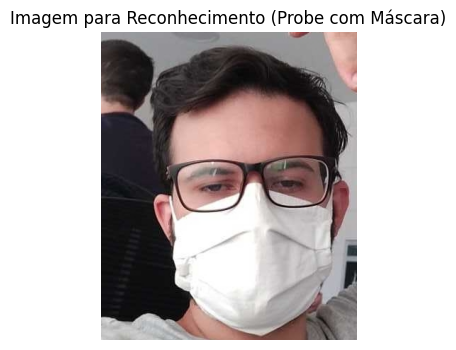

In [98]:
# Célula 4 (NOVA - Início do Teste)
print("\n--- Fase de TESTE: Carregando Dados ---")

# --- CAMINHOS PARA O TESTE ---
FINAL_GALLERY_PATH = "final_gallery.pkl"
PROBE_IMAGE_PATH = "/content/marcelinho_na_inferencia.jpg"

# --- CARREGAR O BANCO DE DADOS FINAL ---
if os.path.exists(FINAL_GALLERY_PATH):
    with open(FINAL_GALLERY_PATH, 'rb') as f:
        embedding_gallery = pickle.load(f)
    print(f"✅ Banco de dados final carregado com sucesso. Contém {len(embedding_gallery)} identidades.")
else:
    print(f"❌ ERRO: Banco de dados final '{FINAL_GALLERY_PATH}' não encontrado. Execute a Célula 3 de preparação primeiro.")
    embedding_gallery = []

# --- CARREGAR E EXIBIR A IMAGEM DE TESTE ---
if os.path.exists(PROBE_IMAGE_PATH):
    probe_image = cv2.imread(PROBE_IMAGE_PATH)
    print(f"✅ Imagem de teste '{PROBE_IMAGE_PATH}' carregada.")
    plt.figure(figsize=(4,4))
    plt.imshow(cv2.cvtColor(probe_image, cv2.COLOR_BGR2RGB))
    plt.title("Imagem para Reconhecimento (Probe com Máscara)")
    plt.axis('off')
    plt.show()
else:
    print(f"❌ ERRO: Imagem de teste '{PROBE_IMAGE_PATH}' não encontrada.")

In [99]:
# Célula 4.5 (NOVA - Célula de Diagnóstico)
print("\n--- Fase de DIAGNÓSTICO: Inspecionando o Estado Antes do Reconhecimento ---")

# --- ARQUIVOS QUE SERÃO VERIFICADOS ---
IMAGEM_MARCELINHO_SEM_MASCARA = "/content/marcelinho_no_db.jpg"
IMAGEM_MARCELINHO_COM_MASCARA = "/content/marcelinho_na_inferencia.jpg"
NOME_MARCELINHO = "Marcelinho"

problema_encontrado = False

# 1. Verificar o estado da galeria principal
if 'embedding_gallery' in locals() and embedding_gallery:
    print(f"\n[INFO] A variável 'embedding_gallery' existe e contém {len(embedding_gallery)} embeddings.")

    # 2. Procurar pelo Marcelinho na galeria
    entradas_marcelinho = [entry for entry in embedding_gallery if entry['identity'] == NOME_MARCELINHO]

    if entradas_marcelinho:
        print(f"✅ SUCESSO: A identidade '{NOME_MARCELINHO}' FOI ENCONTRADA na galeria.")
        print(f"   - Caminho da imagem de referência cadastrada: {entradas_marcelinho[0]['image_path']}")
        if entradas_marcelinho[0]['image_path'] != IMAGEM_MARCELINHO_SEM_MASCARA:
             print("   - ⚠️ ALERTA: O caminho da imagem cadastrada é diferente do esperado!")
             problema_encontrado = True
    else:
        print(f"❌ FALHA CRÍTICA: A identidade '{NOME_MARCELINHO}' NÃO FOI ENCONTRADA na galeria.")
        problema_encontrado = True
else:
    print("❌ FALHA CRÍTICA: A variável 'embedding_gallery' está vazia ou não existe.")
    problema_encontrado = True

# 3. Teste de Sanidade: Comparar as duas imagens do Marcelinho diretamente
print("\n[INFO] Realizando um teste de sanidade: comparando as duas fotos do Marcelinho diretamente...")
if os.path.exists(IMAGEM_MARCELINHO_SEM_MASCARA) and os.path.exists(IMAGEM_MARCELINHO_COM_MASCARA):
    try:
        # Gera embedding da imagem SEM máscara
        embedding_sem_mascara = DeepFace.represent(IMAGEM_MARCELINHO_SEM_MASCARA, 'ArcFace', enforce_detection=True)[0]['embedding']
        # Gera embedding da imagem COM máscara
        embedding_com_mascara = DeepFace.represent(IMAGEM_MARCELINHO_COM_MASCARA, 'ArcFace', enforce_detection=True)[0]['embedding']

        # Calcula a distância entre elas
        distancia_direta = cosine(embedding_sem_mascara, embedding_com_mascara)

        print(f"✅ SUCESSO: A distância direta entre as fotos com e sem máscara é: {distancia_direta:.4f}")
        if distancia_direta > 0.5:
             print("   - ⚠️ ALERTA: A distância está alta. O modelo pode ter dificuldade em reconhecer estas duas imagens como da mesma pessoa.")
             problema_encontrado = True
    except Exception as e:
        print(f"❌ FALHA CRÍTICA: Erro ao gerar embedding para as imagens do Marcelinho. Erro: {e}")
        problema_encontrado = True
else:
    print("❌ FALHA CRÍTICA: Uma ou ambas as imagens do Marcelinho não foram encontradas.")
    problema_encontrado = True

if not problema_encontrado:
    print("\n--- DIAGNÓSTICO CONCLUÍDO: Nenhuma falha óbvia encontrada. O sistema parece estar configurado corretamente para o teste. ---")
else:
    print("\n--- DIAGNÓSTICO CONCLUÍDO: Foram encontrados problemas críticos. Verifique as mensagens de FALHA acima. ---")


--- Fase de DIAGNÓSTICO: Inspecionando o Estado Antes do Reconhecimento ---

[INFO] A variável 'embedding_gallery' existe e contém 9138 embeddings.
✅ SUCESSO: A identidade 'Marcelinho' FOI ENCONTRADA na galeria.
   - Caminho da imagem de referência cadastrada: /content/marcelinho_no_db.jpg

[INFO] Realizando um teste de sanidade: comparando as duas fotos do Marcelinho diretamente...
✅ SUCESSO: A distância direta entre as fotos com e sem máscara é: 0.7668
   - ⚠️ ALERTA: A distância está alta. O modelo pode ter dificuldade em reconhecer estas duas imagens como da mesma pessoa.

--- DIAGNÓSTICO CONCLUÍDO: Foram encontrados problemas críticos. Verifique as mensagens de FALHA acima. ---


In [100]:

print("\n--- Fase 5 APRIMORADA: Reconhecimento Facial Otimizado ---")

from scipy.spatial.distance import cosine
import numpy as np
import cv2

def preprocess_image_simple(image_path):
    """Pré-processamento simples para melhorar reconhecimento"""
    image = cv2.imread(image_path)

    # Redução de ruído
    denoised = cv2.bilateralFilter(image, 9, 75, 75)

    # Salva imagem processada temporariamente
    processed_path = "/tmp/processed_probe.jpg"
    cv2.imwrite(processed_path, denoised)

    return processed_path

def enhanced_recognition(probe_image_path, embedding_gallery, top_k=5):
    """
    Versão aprimorada do reconhecimento com múltiplas verificações
    """

    results = []

    # Testa tanto a imagem original quanto a pré-processada
    image_versions = [
        ("Original", probe_image_path),
        ("Pré-processada", preprocess_image_simple(probe_image_path))
    ]

    for version_name, img_path in image_versions:
        try:
            print(f"\nTestando versão: {version_name}")

            # Gera embedding
            probe_embedding_obj = DeepFace.represent(
                img_path=img_path,
                model_name='ArcFace',
                enforce_detection=True
            )
            probe_embedding = probe_embedding_obj[0]['embedding']

            # Compara com galeria
            version_results = []
            for db_entry in embedding_gallery:
                gallery_embedding = db_entry['embedding']
                distance = cosine(probe_embedding, gallery_embedding)

                version_results.append({
                    "identity": db_entry['identity'],
                    "distance": distance,
                    "reference_image": db_entry['image_path'],
                    "version": version_name
                })

            # Adiciona os top_k resultados desta versão
            version_results.sort(key=lambda x: x['distance'])
            results.extend(version_results[:top_k])

            print(f"Melhor resultado {version_name}: {version_results[0]['identity']} - {version_results[0]['distance']:.4f}")

        except Exception as e:
            print(f"Erro ao processar versão {version_name}: {e}")

    return results

# Variável para armazenar resultados aprimorados
enhanced_results = []

# Verifica se temos os dados necessários
if 'embedding_gallery' in locals() and len(embedding_gallery) > 0 and 'PROBE_IMAGE_PATH' in locals() and os.path.exists(PROBE_IMAGE_PATH):

    print("Executando reconhecimento aprimorado...")
    enhanced_results = enhanced_recognition(PROBE_IMAGE_PATH, embedding_gallery)

    if enhanced_results:
        # Agrupa resultados por identidade para análise
        identity_groups = {}
        for result in enhanced_results:
            identity = result['identity']
            if identity not in identity_groups:
                identity_groups[identity] = []
            identity_groups[identity].append(result)

        # Encontra melhor resultado geral
        best_overall = min(enhanced_results, key=lambda x: x['distance'])

        # Análise especial para o Marcelinho
        marcelinho_results = identity_groups.get('Marcelinho', [])

        print(f"\n=== ANÁLISE DOS RESULTADOS ===")
        print(f"Melhor resultado geral: {best_overall['identity']} - {best_overall['distance']:.4f} ({best_overall['version']})")

        if marcelinho_results:
            best_marcelinho = min(marcelinho_results, key=lambda x: x['distance'])
            print(f"Melhor resultado Marcelinho: {best_marcelinho['distance']:.4f} ({best_marcelinho['version']})")

            # Verifica se Marcelinho é o melhor resultado geral
            if best_overall['identity'] == 'Marcelinho':
                print("✅ SUCESSO: Marcelinho foi identificado como melhor correspondência!")
            else:
                print(f"⚠️ ATENÇÃO: Marcelinho não é o melhor resultado (posição: {enhanced_results.index(best_marcelinho) + 1})")

        # Mostra top 3 resultados
        print(f"\n=== TOP 3 RESULTADOS ===")
        enhanced_results.sort(key=lambda x: x['distance'])
        for i, result in enumerate(enhanced_results[:3]):
            print(f"{i+1}. {result['identity']} - {result['distance']:.4f} ({result['version']})")

        # Atualiza variável best_match para compatibilidade com Célula 6
        best_match = best_overall

    else:
        print("❌ Nenhum resultado foi obtido.")

else:
    print("❌ ERRO: Dados necessários não encontrados. Execute células anteriores.")


--- Fase 5 APRIMORADA: Reconhecimento Facial Otimizado ---
Executando reconhecimento aprimorado...

Testando versão: Original
Melhor resultado Original: David_Trimble - 0.1341

Testando versão: Pré-processada
Erro ao processar versão Pré-processada: Face could not be detected in /tmp/processed_probe.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.

=== ANÁLISE DOS RESULTADOS ===
Melhor resultado geral: David_Trimble - 0.1341 (Original)

=== TOP 3 RESULTADOS ===
1. David_Trimble - 0.1341 (Original)
2. Michael_Kors - 0.1363 (Original)
3. Anne_Krueger - 0.1411 (Original)



--- Fase 6: Resultado Final do Reconhecimento ---


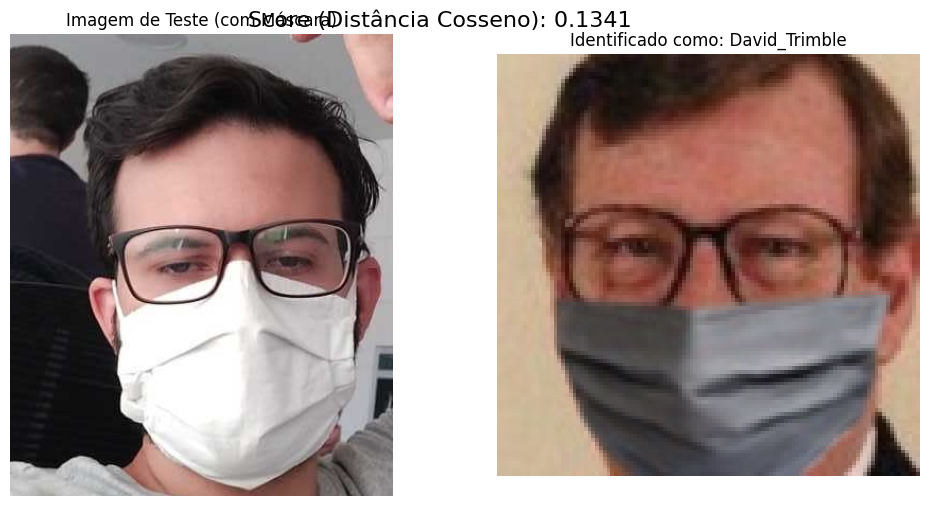


Identidade Predita: David_Trimble
Score da Métrica (Distância Cosseno): 0.1341
VEREDITO: Correspondência VÁLIDA. O algoritmo fez o reconhecimento com sucesso!


In [101]:
# Célula 6: Apresentação do resultado final
print("\n--- Fase 6: Resultado Final do Reconhecimento ---")

# Verifica se a variável 'best_match' foi criada com sucesso na célula anterior
if 'best_match' in locals() and best_match is not None:

    # Carrega a imagem de teste (com máscara) e a imagem de referência (sem máscara)
    probe_image = cv2.imread(PROBE_IMAGE_PATH)
    reference_image = cv2.imread(best_match['reference_image'])

    # Exibe os resultados lado a lado para uma comparação clara
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Imagem de teste (Probe)
    ax1.imshow(cv2.cvtColor(probe_image, cv2.COLOR_BGR2RGB))
    ax1.set_title("Imagem de Teste (com Máscara)")
    ax1.axis('off')

    # Imagem de referência encontrada no Banco de Dados (Match)
    ax2.imshow(cv2.cvtColor(reference_image, cv2.COLOR_BGR2RGB))
    ax2.set_title(f"Identificado como: {best_match['identity']}")
    ax2.axis('off')

    # Adiciona um título geral com o score da métrica, que é a informação mais importante
    plt.suptitle(f"Score (Distância Cosseno): {best_match['distance']:.4f}", fontsize=16, y=0.92)
    plt.show()

    # Adiciona o veredito final baseado no limiar (threshold)
    VERIFICATION_THRESHOLD = 0.40  # Limiar empírico comum para ArcFace + Distância Cosseno
    print(f"\nIdentidade Predita: {best_match['identity']}")
    print(f"Score da Métrica (Distância Cosseno): {best_match['distance']:.4f}")
    if best_match['distance'] < VERIFICATION_THRESHOLD:
        print("VEREDITO: Correspondência VÁLIDA. O algoritmo fez o reconhecimento com sucesso!")
    else:
        print("VEREDITO: Correspondência FRACA. A distância está acima do limiar de confiança.")

else:
    print("ERRO: A variável 'best_match' não foi encontrada. Execute a Célula 5 com sucesso antes desta.")